# Лабораторная работа №3 ОБУЧЕНИЕ С УЧИТЕЛЕМ. ЗАДАЧА КЛАССИФИКАЦИИ 

## Загрузка и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as Pipeline_imb

from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score, confusion_matrix, RocCurveDisplay, classification_report


RNG_SEED = 42
np.random.seed(seed=RNG_SEED)

### Загрузка датасета

In [2]:
df = pd.read_csv('../data/final_data_wine.csv')
df

,Unnamed: 0,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5969,4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
5970,4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
5971,4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
5972,4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5974 entries, 0 to 5973
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            5974 non-null   int64  
 1   fixed acidity         5974 non-null   float64
 2   volatile acidity      5974 non-null   float64
 3   citric acid           5974 non-null   float64
 4   residual sugar        5974 non-null   float64
 5   chlorides             5974 non-null   float64
 6   free sulfur dioxide   5974 non-null   float64
 7   total sulfur dioxide  5974 non-null   float64
 8   density               5974 non-null   float64
 9   pH                    5974 non-null   float64
 10  sulphates             5974 non-null   float64
 11  alcohol               5974 non-null   float64
 12  quality               5974 non-null   int64  
 13  type                  5974 non-null   int64  
dtypes: float64(11), int64(3)
memory usage: 653.5 KB


### Выделеение целевого признака и предиктора, разделение на выборки

In [4]:
X = df.drop(columns=['type'])
y = df['type']
print(X.shape, y.shape)
print(y.value_counts())

(5974, 13) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


### Разделение данных

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, stratify=y
)

# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(4779, 13) (1195, 13)
(4779,) (1195,)


Задача бинарной классификации (2 признака 0,1 - белое и красное вино). В данных имеется явный дисбаланс классов - красного вина в 4 раза меньше белого

### Балансировка hold-out

In [6]:
oversample = SMOTE()
X_train_bal, y_train_bal = oversample.fit_resample(X_train, y_train)

print(f'new train label count: {y_train_bal.value_counts()}')

new train label count: type
0    3660
1    3660
Name: count, dtype: int64


In [7]:
def format_cv_table(cv_results, model_name=None):
    metric_mapping = {
        'test_f1': 'F1',
        'test_accuracy': 'Accuracy',
        'test_precision': 'Precision',
        'test_recall': 'Recall',
    }
    
    data = {'Fold': list(range(10))}
    for cv_key, col_name in metric_mapping.items():
        if cv_key in cv_results:
            data[col_name] = cv_results[cv_key]
            
    df = pd.DataFrame(data)
    df.set_index('Fold', inplace=True)
    
    mean_vals = df.mean()
    std_vals = df.std()

    df_display = df.copy()
    df_display.loc['Mean'] = mean_vals
    df_display.loc['Std'] = std_vals
    
    print(f"Результаты 10-Fold CV для {model_name}:")
    
    df_styled = df_display.style.format({
        'F1': '{:.4f}',
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
    }).apply(
        lambda row: ['background-color: yellow' if row.name == 'Mean' else '' for _ in row],
        axis=1
    )
    
    display(df_styled)

def get_metrics_dict(y_true, y_pred):
    return {
        'F1': round(f1_score(y_true, y_pred, average='weighted'), 2),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),  
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall': round(recall_score(y_true, y_pred, average='weighted'), 4)
    }

In [11]:
neighbors = 3
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    f"kNN (k={neighbors})": KNeighborsClassifier(n_neighbors=neighbors),
    "Naive Bayes": GaussianNB(),
    "SVC (Linear)": SVC(kernel='linear', random_state=42, cache_size=4000),
    "SVC (polynomial)": SVC(kernel='poly', random_state=42, cache_size=4000),
    "SVC (sygmoid)": SVC(kernel='sigmoid', random_state=42, cache_size=4000),
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
metrics = ['F1', 'Accuracy', 'Precision', 'Recall']
cv_mapping = {'test_f1': 'F1', 'test_accuracy': 'Accuracy', 
              'test_precision': 'Precision', 'test_recall': 'Recall'}

holdout_rows = []
cv_rows = []
trained_models = {}

In [12]:
def fmt(val, is_f1=False):
    prec = 2 if is_f1 else 4
    return f"{val:.{prec}f}".rstrip('0').rstrip('.')

def train_model(name, model):
    global cv, cv_mapping, metrics, holdout_rows, cv_rows, trained_models

    print(f"\nОбучение: {name}")
    model_pipeline = Pipeline_imb([
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    cv_results = cross_validate(
        model_pipeline, X_train, y_train,
        cv=cv, scoring=['accuracy', 'f1', 'precision', 'recall'],
        n_jobs=-1
    )
    
    model_pipeline.fit(X_train_bal, y_train_bal) 
    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)
    trained_models[name] = model_pipeline

    train_m = get_metrics_dict(y_train, y_pred_train)
    test_m = get_metrics_dict(y_test, y_pred_test)

    row_holdout = {'Classifier': name}
    for metric in metrics:
        row_holdout[('Train Data', metric)] = fmt(train_m[metric], is_f1=(metric=='F1'))
        row_holdout[('Test Data', metric)]  = fmt(test_m[metric], is_f1=(metric=='F1'))
    holdout_rows.append(row_holdout)

    row_cv = {'Classifier': name}
    
    for metric in metrics:
        row_cv[('Hold-out (test)', metric)] = fmt(test_m[metric], is_f1=(metric=='F1'))
        
    for cv_key, metric_name in cv_mapping.items():
        mean_val = cv_results[cv_key].mean()
        std_val  = cv_results[cv_key].std()
        row_cv[('K-fold (CV)', metric_name)] = f"{fmt(mean_val, is_f1=(metric_name=='F1'))} ± {fmt(std_val, is_f1=(metric_name=='F1'))}"
    cv_rows.append(row_cv)

    
    format_cv_table(cv_results, name)
    print("train: ", train_m)
    print("test: ", test_m)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_test))
    RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)
    plt.show()


Обучение: Logistic Regression
Результаты 10-Fold CV для Logistic Regression:


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9868,0.9937,0.9739,1.0000
1,0.9956,0.9979,0.9912,1.0000
2,0.9956,0.9979,0.9912,1.0000
3,0.9956,0.9979,0.9912,1.0000
4,1.0000,1.0000,1.0000,1.0000
5,0.9821,0.9916,0.9821,0.9821
6,0.9821,0.9916,0.9821,0.9821
7,0.9911,0.9958,0.9911,0.9911
8,0.9820,0.9916,0.9909,0.9732


train:  {'F1': 1.0, 'Accuracy': 0.9962, 'Precision': 0.9962, 'Recall': 0.9962}
test:  {'F1': 1.0, 'Accuracy': 0.9967, 'Precision': 0.9967, 'Recall': 0.9967}
Confusion Matrix:
[[912   3]
 [  1 279]]


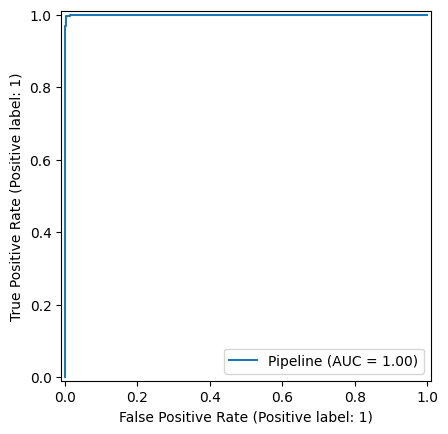


Обучение: kNN (k=3)
Результаты 10-Fold CV для kNN (k=3):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.8560,0.9226,0.7586,0.9821
1,0.9198,0.9603,0.8720,0.9732
2,0.8724,0.9351,0.8092,0.9464
3,0.8606,0.9268,0.7770,0.9643
4,0.8952,0.9456,0.8162,0.9911
5,0.8755,0.9351,0.7956,0.9732
6,0.8816,0.9393,0.8120,0.9643
7,0.9198,0.9603,0.8720,0.9732
8,0.8889,0.9435,0.8244,0.9643


train:  {'F1': 0.99, 'Accuracy': 0.9851, 'Precision': 0.986, 'Recall': 0.9851}
test:  {'F1': 0.95, 'Accuracy': 0.9506, 'Precision': 0.956, 'Recall': 0.9506}
Confusion Matrix:
[[864  51]
 [  8 272]]


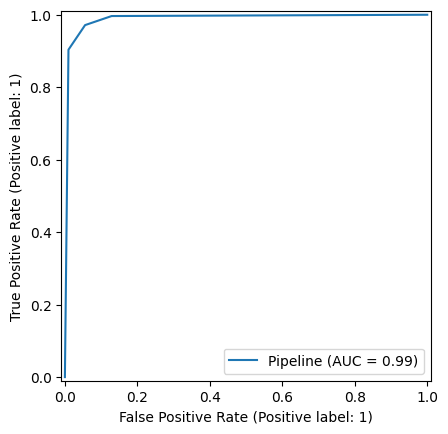


Обучение: Naive Bayes
Результаты 10-Fold CV для Naive Bayes:


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9868,0.9937,0.9739,1.0000
1,0.9911,0.9958,0.9911,0.9911
2,0.9912,0.9958,0.9825,1.0000
3,0.9956,0.9979,0.9912,1.0000
4,0.9697,0.9854,0.9412,1.0000
5,0.9778,0.9895,0.9735,0.9821
6,0.9649,0.9833,0.9483,0.9821
7,0.9867,0.9937,0.9823,0.9911
8,0.9776,0.9895,0.9820,0.9732


train:  {'F1': 0.99, 'Accuracy': 0.992, 'Precision': 0.9921, 'Recall': 0.992}
test:  {'F1': 0.99, 'Accuracy': 0.99, 'Precision': 0.9902, 'Recall': 0.99}
Confusion Matrix:
[[905  10]
 [  2 278]]


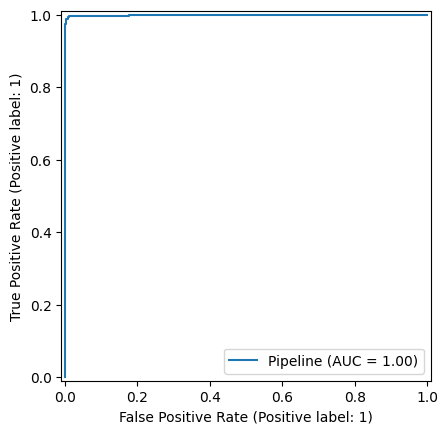


Обучение: SVC (Linear)
Результаты 10-Fold CV для SVC (Linear):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.9825,0.9916,0.9655,1.0000
1,0.9956,0.9979,0.9912,1.0000
2,0.9956,0.9979,0.9912,1.0000
3,0.9868,0.9937,0.9739,1.0000
4,1.0000,1.0000,1.0000,1.0000
5,0.9910,0.9958,1.0000,0.9821
6,0.9865,0.9937,0.9910,0.9821
7,0.9955,0.9979,1.0000,0.9911
8,0.9820,0.9916,0.9909,0.9732


train:  {'F1': 1.0, 'Accuracy': 0.9964, 'Precision': 0.9964, 'Recall': 0.9964}
test:  {'F1': 0.99, 'Accuracy': 0.995, 'Precision': 0.995, 'Recall': 0.995}
Confusion Matrix:
[[911   4]
 [  2 278]]


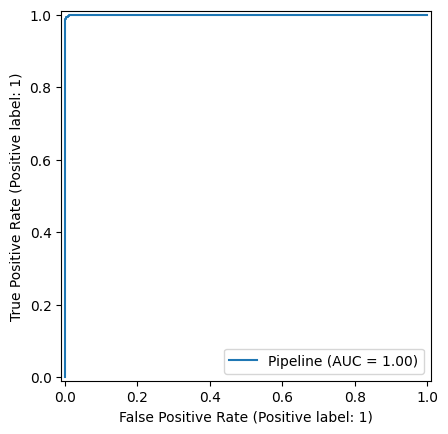


Обучение: SVC (polynomial)
Результаты 10-Fold CV для SVC (polynomial):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.6512,0.7490,0.4828,1.0000
1,0.6588,0.7573,0.4912,1.0000
2,0.6550,0.7531,0.4870,1.0000
3,0.6310,0.7259,0.4609,1.0000
4,0.6400,0.7364,0.4706,1.0000
5,0.6292,0.7238,0.4590,1.0000
6,0.6850,0.7845,0.5209,1.0000
7,0.6809,0.7803,0.5161,1.0000
8,0.6310,0.7259,0.4609,1.0000


train:  {'F1': 0.77, 'Accuracy': 0.7527, 'Precision': 0.8797, 'Recall': 0.7527}
test:  {'F1': 0.77, 'Accuracy': 0.7556, 'Precision': 0.8804, 'Recall': 0.7556}
Confusion Matrix:
[[623 292]
 [  0 280]]


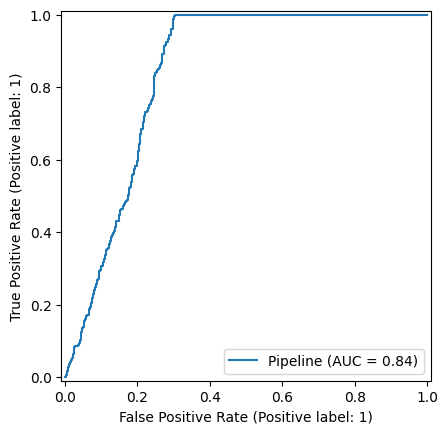


Обучение: SVC (sygmoid)
Результаты 10-Fold CV для SVC (sygmoid):


,F1,Accuracy,Precision,Recall
Fold,,,,
0,0.2660,0.4226,0.1894,0.4464
1,0.2344,0.3849,0.1654,0.4018
2,0.2454,0.3954,0.1734,0.4196
3,0.2588,0.4247,0.1853,0.4286
4,0.2857,0.4351,0.2030,0.4821
5,0.2299,0.3975,0.1641,0.3839
6,0.1890,0.3536,0.1338,0.3214
7,0.1984,0.3745,0.1418,0.3304
8,0.1983,0.3912,0.1434,0.3214


train:  {'F1': 0.44, 'Accuracy': 0.3951, 'Precision': 0.5608, 'Recall': 0.3951}
test:  {'F1': 0.42, 'Accuracy': 0.3774, 'Precision': 0.5407, 'Recall': 0.3774}
Confusion Matrix:
[[352 563]
 [181  99]]


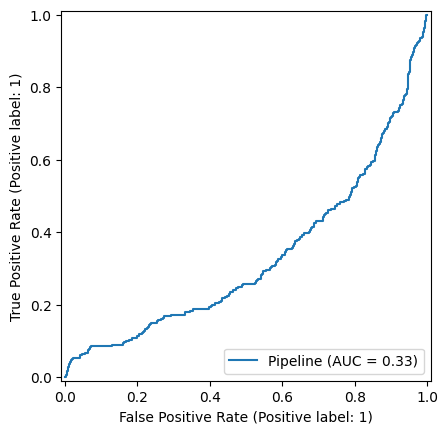

In [13]:
for name, model in classifiers.items():
    train_model(name, model)

In [14]:
cols_2 = pd.MultiIndex.from_product([['Train Data', 'Test Data'], ['F1', 'Accuracy', 'Precision', 'Recall']])
df_sample2 = pd.DataFrame(holdout_rows).set_index('Classifier').reindex(columns=cols_2)
display(df_sample2.style.set_caption("Образец 2: Результаты метода Hold-out"))

cols_3 = pd.MultiIndex.from_product([['Hold-out (test)', 'K-fold (CV)'], ['F1', 'Accuracy', 'Precision', 'Recall']])
df_sample3 = pd.DataFrame(cv_rows).set_index('Classifier').reindex(columns=cols_3)
display(df_sample3.style.set_caption("Образец 3: Сравнение Hold-out и K-Fold"))

Смотря на количество ошибок 1 и 2 рода (3 и 1 соотвественно), можно сделать вывод, что модель очень хорошо справляется с класификацей предоствленных данных. На тренировочных данных сохраняется такое же низкое соотношение. Итого на 1192 приходятся 3 ошибки, то есть 0.25% приходятся на неверный прогноз. Рог кривая почти полностью соотвестует идеальной, что говорит о черезвучайно хорошой предсказательной силе данной модели, что даже немного странно. Модель работате практически идеально на предоставленных данных

## Классификаторы

In [ ]:
# model_pipeline = Pipeline_imb([
#     ('smote', SMOTE(random_state=42)),
#     ('clf', LogisticRegression(max_iter=1000, random_state=42))
# ])

# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# cv_results = cross_validate(
#     model_pipeline, 
#     X_train, y_train,
#     cv=cv, 
#     scoring=['accuracy', 'f1', 'precision', 'recall']
# )

# format_cv_table(cv_results, model_name="LogReg Pipeline")

# model_pipeline.fit(X_train, y_train) 
# y_pred_test = model_pipeline.predict(X_test)

# display(get_holdout_metrics(y_test, y_pred_test, 'LogisticRegression'))
# RocCurveDisplay.from_estimator(model_pipeline, X_test, y_test)

### Логистическая регрессия

In [ ]:
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# logictic_regression = LogisticRegression(random_state=42, max_iter=1000)
# cv_res = cross_validate(logictic_regression, X_train_bal, y_train_bal, 
#                         cv=10, scoring=['f1','accuracy','precision','recall'])
# format_cv_table(cv_res, model_name=logictic_regression)

In [ ]:
# logictic_regression.fit(X_train_bal, y_train_bal) 

# y_pred_train = logictic_regression.predict(X_train_bal)
# y_pred_test = logictic_regression.predict(X_test)

# print(accuracy_score(y_test, y_pred_test))

# confusion_matrix(y_train_bal, y_pred_train)


In [ ]:
# confusion_matrix(y_test, y_pred_test)

In [ ]:
# RocCurveDisplay.from_estimator(logictic_regression, X_test, y_test)

In [ ]:
# print(classification_report(y_test, y_pred_test))

In [ ]:
# correlations = X_train_bal.corrwith(y_train_bal).abs().sort_values(ascending=False)
# print("Корреляции признаков с целевой переменной:")
# print(correlations)

In [ ]:
# cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
# knn = KNeighborsClassifier()
# cv_res = cross_validate(knn, X_train_bal, y_train_bal, 
#                         cv=10, scoring=['f1','accuracy','precision','recall'])
# format_cv_table(cv_res, model_name=knn)

In [ ]:
# logictic_regression.fit(X_train_bal, y_train_bal) 

# y_pred_train = logictic_regression.predict(X_train_bal)
# y_pred_test = logictic_regression.predict(X_test)

# print(accuracy_score(y_test, y_pred_test))

# print(confusion_matrix(y_train_bal, y_pred_train))

In [ ]:
# print(confusion_matrix(y_test, y_pred_test))